In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 25

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
unique brain regions ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
there are 64 MEC cells
there are 49 PARA cells
there are 0 PRE cells
there are 39 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 152 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for

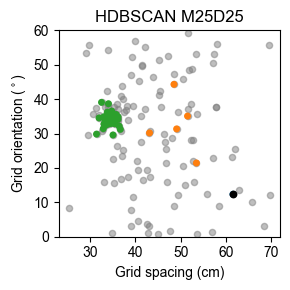

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
module 1 contains cells from ['ENTm2' 'PAR' 'VISpl2/3']
module 0 contains cells from ['ENTm2' 'PAR' 'VISpl2/3']
25 25
for module 1, there are 30 cells
for module 0, there are 5 cells
plotting vr rate maps using cluster_ids [3, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 109, 111, 120, 207, 214, 215, 219, 221, 227, 230, 231, 232, 233, 234, 235, 250, 264]
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218


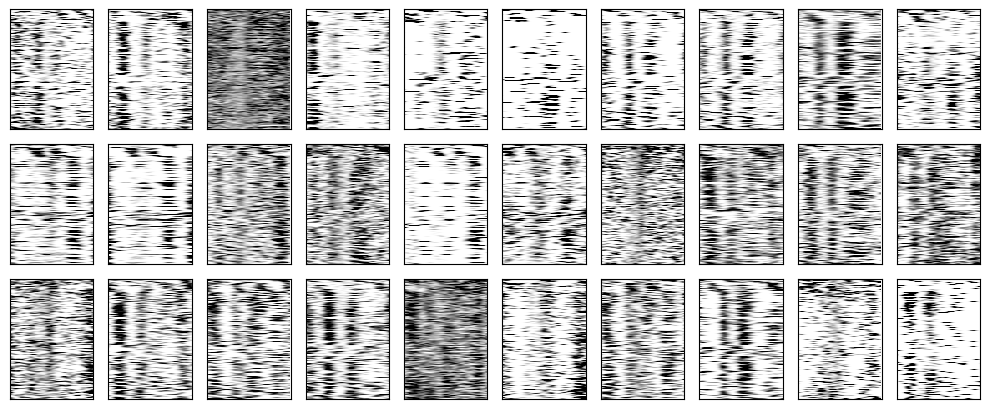

plotting vr rate maps using cluster_ids [11, 106, 209, 245, 293]
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218


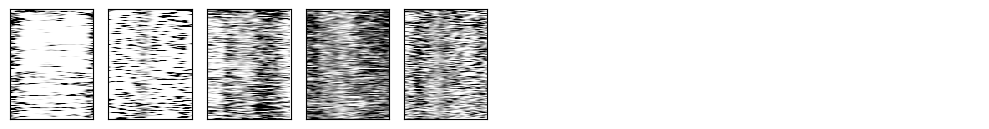

plotting vr rate maps using cluster_ids [1, 13, 16, 17, 32, 72, 73, 79, 80, 82, 85, 88, 89, 95, 97, 102, 110, 112, 123, 127, 130, 141, 148, 169, 172, 173, 174, 175, 176, 177, 178, 179, 185, 186, 189, 191, 193, 196, 197, 198, 199, 202, 203, 205, 206, 210, 217, 220, 222, 225, 228, 229, 238, 241, 242, 246, 249, 252, 253, 262, 265, 273, 280, 281, 283, 284, 285, 287, 297, 309, 310, 311, 312, 316]
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n t

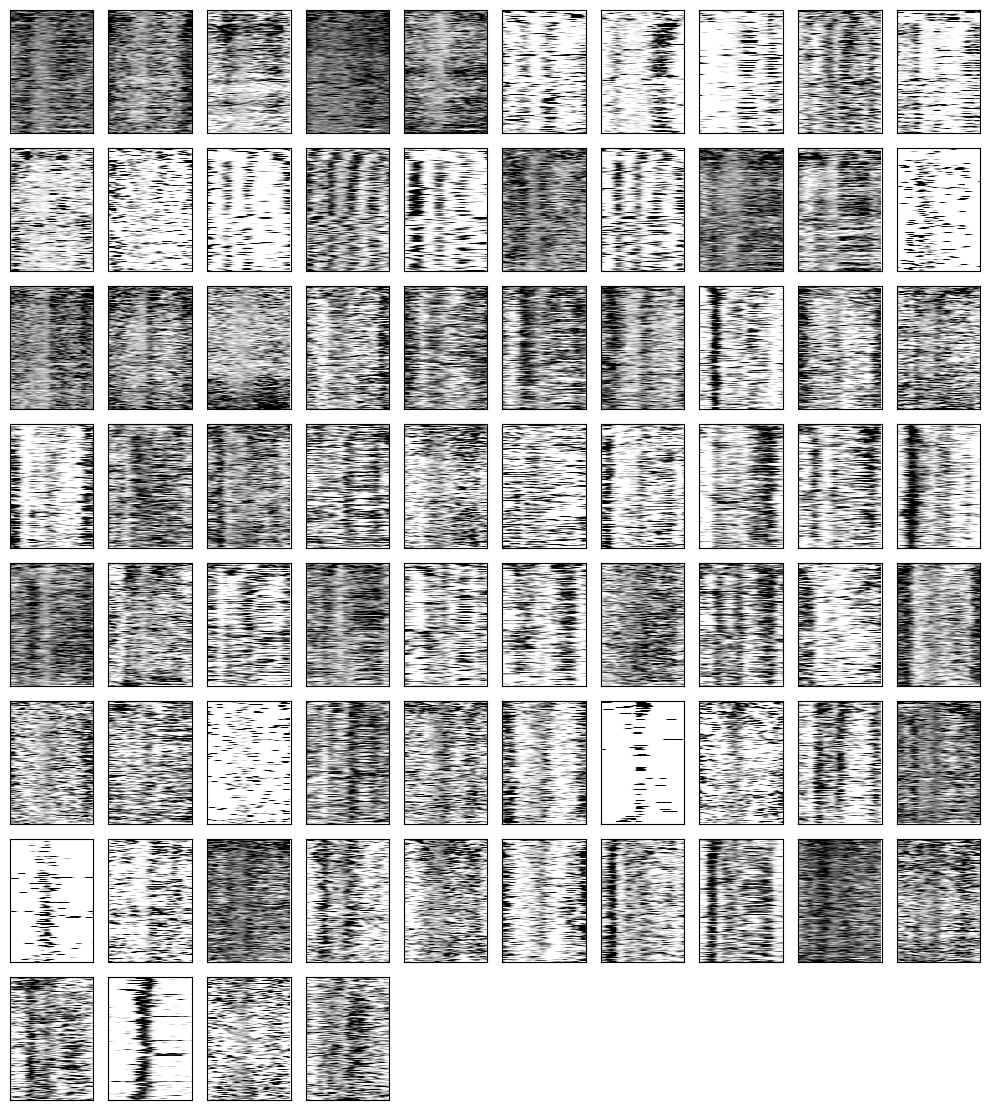

plotting vr rate maps using cluster_ids [8, 9, 10, 30, 31, 46, 60, 90, 92, 100, 117, 133, 138, 143, 149, 180, 181, 183, 188, 204, 211, 224, 239, 240, 248, 254, 256, 257, 288, 291, 295, 303, 306, 307, 315, 322]
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218


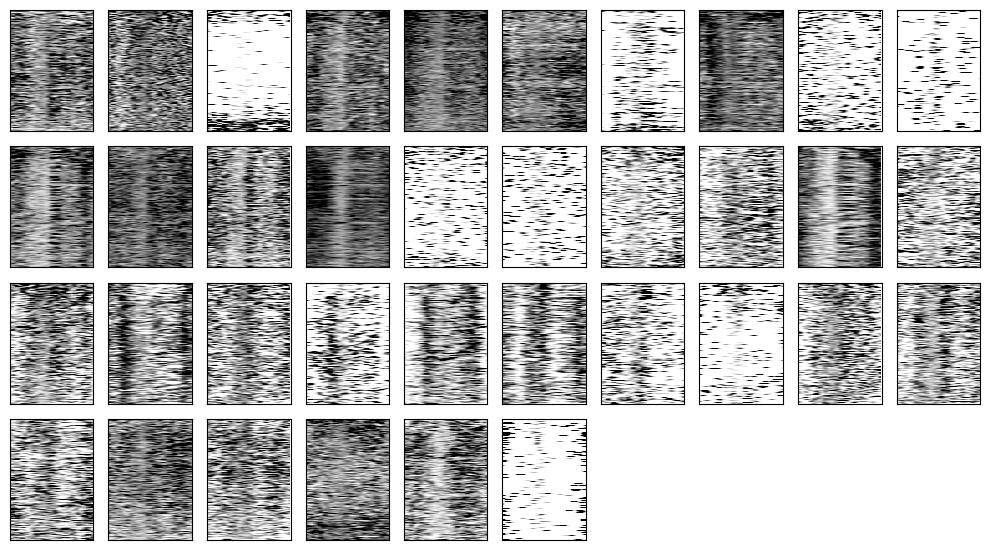

plotting vr rate maps using cluster_ids [3, 11, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 106, 109, 111, 120, 170, 207, 209, 214, 215, 219, 221, 227, 230, 231, 232, 233, 234, 235, 245, 250, 264, 293]
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218


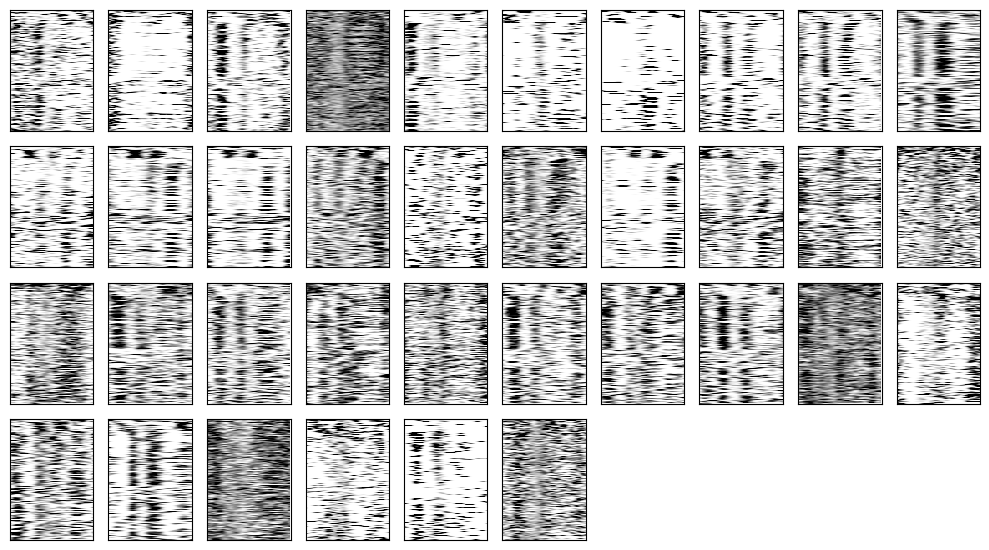

plotting vr rate maps using cluster_ids []


In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

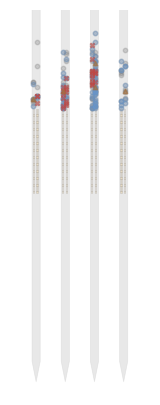

In [4]:
markers = ['x', '^', 's']
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(4, 5), squeeze=False)
plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', contacts_alpha=0.3)
ax[0,0].scatter(all_by_anatomy['probe_x'], all_by_anatomy['probe_y'], color='tab:grey', alpha=0.3, s=10)
ax[0,0].scatter(ngs['probe_x'], ngs['probe_y'], color='#6897CD', alpha=0.3, s=10)
m_colors = ['#c04744', "#a36f3d", "#c0b244", "#3171ae", "#22220D"]
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,0].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6, color=m_colors[m], marker=markers[m], s=10)
ax[0,0].set_xlim(-200, 1000)
ax[0,0].set_ylim(-300, 3000)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe.pdf',  bbox_inches='tight')
plt.show()

In [7]:
print(f' there are {len(gcs)} grid cells, {len(ngs)} non grid spatial cells and {len(ns)} non spatial cells')

 there are 36 grid cells, 74 non grid spatial cells and 36 non spatial cells


In [5]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

In [6]:
cov_tcs_time_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

make a test case grid cell

n trials: 218
n trials: 218


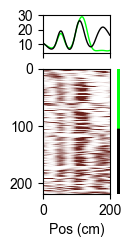

n trials: 218
n trials: 218


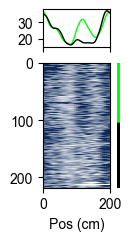

In [46]:
test_grid_cell_id = 91
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=[test_grid_cell_id], label='GC', figpath='/Users/harryclark/Desktop/M25D25/')
test_non_grid_cell_id = 13
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=[test_non_grid_cell_id], label='NGS', figpath='/Users/harryclark/Desktop/M25D25/')

In [47]:
ns.cluster_id


0       8
1       9
2      10
3      30
4      31
5      46
6      60
7      90
8      92
9     100
10    117
11    133
12    138
13    143
14    149
15    180
16    181
17    183
18    188
19    204
20    211
21    224
22    239
23    240
24    248
25    254
26    256
27    257
28    288
29    291
30    295
31    303
32    306
33    307
34    315
35    322
Name: cluster_id, dtype: object

In [95]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

comodular_grid_cell_ids = np.array(g_m_cluster_ids[0])
comodular_grid_cell_ids = comodular_grid_cell_ids[comodular_grid_cell_ids != test_grid_cell_id]

ngs_ids = np.array(ngs.cluster_id.values)
ngs_ids = ngs_ids[ngs_ids != test_non_grid_cell_id]
# randomize ngs_ids because id names are related to the anatomical location
np.random.seed(4444)
np.random.shuffle(ngs_ids)

y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
y_NGS = np.array(tcs_time[test_non_grid_cell_id]) # target variable is the test non grid spatial cell

X  = np.stack([pos_in_time]).T # pos in time
X_1gc = np.stack([pos_in_time, np.array(tcs_time[list(comodular_grid_cell_ids)[0]])]).T # grid cell 10 + pos in time
X_5gc = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(comodular_grid_cell_ids)[:5]]) # grid cell 1-5 + pos in time
X_10gc = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(comodular_grid_cell_ids)[:10]]) # grid cell 1-10 + pos in time
X_15gc = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(comodular_grid_cell_ids)[:15]]) # grid cell 1-15 + pos in time
X_20gc = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(comodular_grid_cell_ids)[:20]]) # grid cell 1-20 + pos in time

X_1NGS = np.stack([pos_in_time, np.array(tcs_time[list(ngs_ids)[0]])]).T # non grid spatial cell 1 + pos in time
X_5NGS = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(ngs_ids)[:5]]) # non grid spatial cell 1-5 + pos in time
X_10NGS = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(ngs_ids)[:10]]) # non grid spatial cell 1-10 + pos in time
X_15NGS = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(ngs_ids)[:15]]) # non grid spatial cell 1-15 + pos in time
X_20NGS = np.column_stack([pos_in_time] + [np.array(tcs_time[cid]) for cid in list(ngs_ids)[:20]]) # non grid spatial cell 1-20 + pos in time

# test grid cell using population of grid cells
Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1gc, pR2_cv_1gc = xgb_history.fit_cv(X_1gc, y, verbose = 0, continuous_folds = True)
Y_hat_g5gc, pR2_cv_5gc = xgb_history.fit_cv(X_5gc, y, verbose = 0, continuous_folds = True)
Y_hat_g10gc, pR2_cv_10gc = xgb_history.fit_cv(X_10gc, y, verbose = 0, continuous_folds = True);
Y_hat_g15gc, pR2_cv_15gc = xgb_history.fit_cv(X_15gc, y, verbose = 0, continuous_folds = True);
Y_hat_g20gc, pR2_cv_20gc = xgb_history.fit_cv(X_20gc, y, verbose = 0, continuous_folds = True)

# test non grid spatial cell using population of grid cells
Y_hat_p_NGS, pR2_cv_p_NGS = xgb_history.fit_cv(X, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g1gc_NGS, pR2_cv_1gc_NGS = xgb_history.fit_cv(X_1gc, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g5gc_NGS, pR2_cv_5gc_NGS = xgb_history.fit_cv(X_5gc, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g10gc_NGS, pR2_cv_10gc_NGS = xgb_history.fit_cv(X_10gc, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g15gc_NGS, pR2_cv_15gc_NGS = xgb_history.fit_cv(X_15gc, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g20gc_NGS, pR2_cv_20gc_NGS = xgb_history.fit_cv(X_20gc, y_NGS, verbose = 0, continuous_folds = True)

# test grid cell using population of non grid spatial cells
Y_hat_p_GC2, pR2_cv_p_GC2 = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1gc_GC2, pR2_cv_1gc_GC2 = xgb_history.fit_cv(X_1NGS, y, verbose = 0, continuous_folds = True)
Y_hat_g5gc_GC2, pR2_cv_5gc_GC2 = xgb_history.fit_cv(X_5NGS, y, verbose = 0, continuous_folds = True)
Y_hat_g10gc_GC2, pR2_cv_10gc_GC2 = xgb_history.fit_cv(X_10NGS, y, verbose = 0, continuous_folds = True)
Y_hat_g15gc_GC2, pR2_cv_15gc_GC2 = xgb_history.fit_cv(X_15NGS, y, verbose = 0, continuous_folds = True)
Y_hat_g20gc_GC2, pR2_cv_20gc_GC2 = xgb_history.fit_cv(X_20NGS, y, verbose = 0, continuous_folds = True)

# test non grid cell using population of non grid spatial cells
Y_hat_p_GC2_NGS, pR2_cv_p_GC2_NGS = xgb_history.fit_cv(X, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g1gc_GC2_NGS, pR2_cv_1gc_GC2_NGS = xgb_history.fit_cv(X_1NGS, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g5gc_GC2_NGS, pR2_cv_5gc_GC2_NGS = xgb_history.fit_cv(X_5NGS, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g10gc_GC2_NGS, pR2_cv_10gc_GC2_NGS = xgb_history.fit_cv(X_10NGS, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g15gc_GC2_NGS, pR2_cv_15gc_GC2_NGS = xgb_history.fit_cv(X_15NGS, y_NGS, verbose = 0, continuous_folds = True)
Y_hat_g20gc_GC2_NGS, pR2_cv_20gc_GC2_NGS = xgb_history.fit_cv(X_20NGS, y_NGS, verbose = 0, continuous_folds = True)

# hack, using the non-spatial cell ids to get the expected spikes into compute_vr_tcs_using_ expected_spikes
expected_spikes = {8: Y_hat_p,
                   9: Y_hat_g1gc,
                   10: Y_hat_g5gc,
                   30: Y_hat_g10gc,
                   31: Y_hat_g15gc,
                   46: Y_hat_g20gc,
                   60: Y_hat_p_NGS,
                   90: Y_hat_g1gc_NGS,
                   92: Y_hat_g5gc_NGS,
                   100: Y_hat_g10gc_NGS,
                   117: Y_hat_g15gc_NGS,
                   133: Y_hat_g20gc_NGS,
                   138: Y_hat_p_GC2,
                   143: Y_hat_g1gc_GC2,
                   149: Y_hat_g5gc_GC2,
                   180: Y_hat_g10gc_GC2,
                   181: Y_hat_g15gc_GC2,
                   183: Y_hat_g20gc_GC2,
                   188: Y_hat_p_GC2_NGS,
                   204: Y_hat_g1gc_GC2_NGS,
                   211: Y_hat_g5gc_GC2_NGS,
                   224: Y_hat_g10gc_GC2_NGS,
                   239: Y_hat_g15gc_GC2_NGS,
                   240: Y_hat_g20gc_GC2_NGS,
                    }

using expected spikes for cell 8
using expected spikes for cell 9
using expected spikes for cell 10
using expected spikes for cell 30
using expected spikes for cell 31
using expected spikes for cell 46
using expected spikes for cell 60
using expected spikes for cell 90
using expected spikes for cell 92
using expected spikes for cell 100
using expected spikes for cell 117
using expected spikes for cell 133
using expected spikes for cell 138
using expected spikes for cell 143
using expected spikes for cell 149
using expected spikes for cell 180
using expected spikes for cell 181
using expected spikes for cell 183
using expected spikes for cell 188
using expected spikes for cell 204
using expected spikes for cell 211
using expected spikes for cell 224
using expected spikes for cell 239
using expected spikes for cell 240
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n t

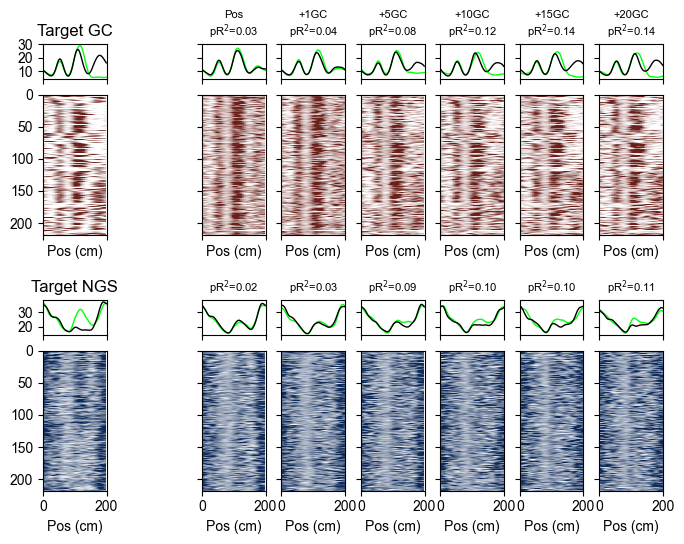

In [96]:
source_path = '/Users/harryclark/Downloads/COHORT12/'
tl = 200

tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path)
tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)

reconstructed_tcs = {}
trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)

fig, ax = plt.subplots(ncols=8, nrows=5, figsize=(rm_figsize[0]*8, rm_figsize[1]*1.45*2.5), 
                       sharex=True, sharey='row', height_ratios=[0.25, 1, 0.25, 0.25, 1], width_ratios=[1,1,1,1,1,1,1,1])

# get the original gc
tc = tcs[test_grid_cell_id]
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
tcz = zscore(tc)
plot_firing_rate_map(ax[1,0], tc, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#69201a'))
for group in np.unique(trial_groups):
    x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
    ax[0,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
ax[0,0].set_title(f'Target GC')
# then leave a blank column

# then plot reconstucted rate maps
for id, col, title, pR2_col in zip([8, 9, 10, 30, 31, 46],
                          [2, 3, 4, 5, 6, 7], 
                          ['Pos', '+1GC', '+5GC', '+10GC', '+15GC', '+20GC'],
                          [pR2_cv_p, pR2_cv_1gc, pR2_cv_5gc, pR2_cv_10gc, pR2_cv_15gc, pR2_cv_20gc]): # ids of the covariates
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)
    plot_firing_rate_map(ax[1, col], tc_es, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#69201a'))
    for group in np.unique(trial_groups):
        x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
        ax[0, col].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    ax[1,col].set_xlabel('Pos (cm)')
    ax[1,col].set_xlim([0,200])
    pR2_col = np.nanmean(pR2_col)
    ax[0,col].set_title(f'{title}\npR$^2$={pR2_col:.2f}', fontsize=8)
ax[1,0].set_xlabel('Pos (cm)') 
ax[1,1].axis('off')
ax[0,1].axis('off')


# get the original ngs
tc = tcs[test_non_grid_cell_id]
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
tcz = zscore(tc)
plot_firing_rate_map(ax[4,0], tc, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#0d2958'))
for group in np.unique(trial_groups):
    x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
    ax[3,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
ax[3,0].set_title(f'Target NGS')


# then plot reconstucted rate maps
for id, col, title, pR2_col in zip([60, 90, 92, 100, 117, 133], 
                          [2, 3, 4, 5, 6, 7], 
                          ['Pos', '+1GC', '+5GC', '+10GC', '+15GC', '+20GC'],
                          [pR2_cv_p_GC2_NGS, pR2_cv_1gc_NGS, pR2_cv_5gc_NGS, pR2_cv_10gc_NGS, pR2_cv_15gc_NGS, pR2_cv_20gc_NGS]): # ids of the covariates
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)
    plot_firing_rate_map(ax[4, col], tc_es, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#0d2958'))
    for group in np.unique(trial_groups):
        x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
        ax[3, col].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    ax[4,col].set_xlabel('Pos (cm)')
    ax[4,col].set_xlim([0,200])
    pR2_col = np.nanmean(pR2_col)
    ax[3,col].set_title(f'pR$^2$={pR2_col:.2f}', fontsize=8)
ax[4,0].set_xlabel('Pos (cm)') 
ax[4,1].axis('off')
ax[3,1].axis('off')
for i in range(8):
    ax[2,i].axis('off')

plt.subplots_adjust(wspace=0.25)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_reconstruction_example_using_GC_as_covariate.pdf',  bbox_inches='tight')
plt.show()


using expected spikes for cell 8
using expected spikes for cell 9
using expected spikes for cell 10
using expected spikes for cell 30
using expected spikes for cell 31
using expected spikes for cell 46
using expected spikes for cell 60
using expected spikes for cell 90
using expected spikes for cell 92
using expected spikes for cell 100
using expected spikes for cell 117
using expected spikes for cell 133
using expected spikes for cell 138
using expected spikes for cell 143
using expected spikes for cell 149
using expected spikes for cell 180
using expected spikes for cell 181
using expected spikes for cell 183
using expected spikes for cell 188
using expected spikes for cell 204
using expected spikes for cell 211
using expected spikes for cell 224
using expected spikes for cell 239
using expected spikes for cell 240
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n trials: 218
n t

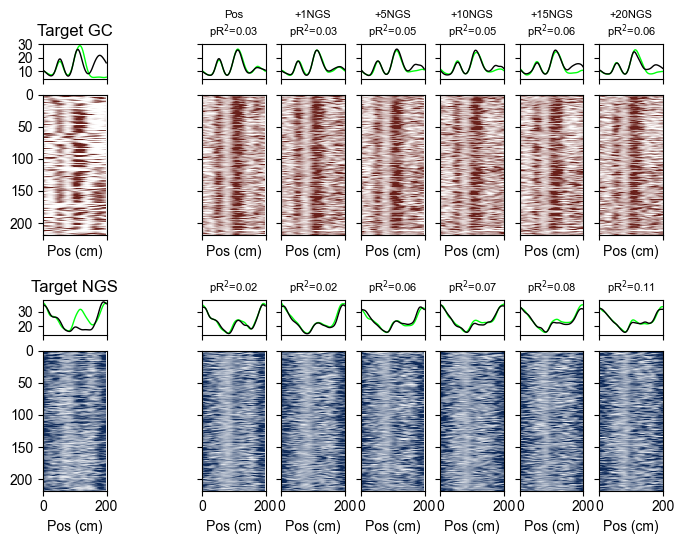

: 

In [ ]:
source_path = '/Users/harryclark/Downloads/COHORT12/'
tl = 200

tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path)
tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)

reconstructed_tcs = {}
trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)

fig, ax = plt.subplots(ncols=8, nrows=5, figsize=(rm_figsize[0]*8, rm_figsize[1]*1.45*2.5), 
                       sharex=True, sharey='row', height_ratios=[0.25, 1, 0.25, 0.25, 1], width_ratios=[1,1,1,1,1,1,1,1])

# get the original gc
tc = tcs[test_grid_cell_id]
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
tcz = zscore(tc)
plot_firing_rate_map(ax[1,0], tc, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#69201a'))
for group in np.unique(trial_groups):
    x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
    ax[0,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
ax[0,0].set_title(f'Target GC')
# then leave a blank column

# then plot reconstucted rate maps
for id, col, title, pR2_col in zip([138, 143, 149, 180, 181, 183], 
                          [2, 3, 4, 5, 6, 7], 
                          ['Pos', '+1NGS', '+5NGS', '+10NGS', '+15NGS', '+20NGS'],
                          [pR2_cv_p_GC2, pR2_cv_1gc_GC2, pR2_cv_5gc_GC2, pR2_cv_10gc_GC2, pR2_cv_15gc_GC2, pR2_cv_20gc_GC2]): # ids of the covariates
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)
    plot_firing_rate_map(ax[1, col], tc_es, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#69201a'))
    for group in np.unique(trial_groups):
        x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
        ax[0, col].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    ax[1,col].set_xlabel('Pos (cm)')
    ax[1,col].set_xlim([0,200])
    pR2_col = np.nanmean(pR2_col)
    ax[0,col].set_title(f'{title}\npR$^2$={pR2_col:.2f}', fontsize=8)
ax[1,0].set_xlabel('Pos (cm)') 
ax[1,1].axis('off')
ax[0,1].axis('off')


# get the original ngs
tc = tcs[test_non_grid_cell_id]
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
tcz = zscore(tc)
plot_firing_rate_map(ax[4,0], tc, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#0d2958'))
for group in np.unique(trial_groups):
    x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
    ax[3,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
ax[3,0].set_title(f'Target NGS')


# then plot reconstucted rate maps
for id, col, title, pR2_col in zip([188, 204, 211, 224, 239, 240],
                          [2, 3, 4, 5, 6, 7], 
                          ['Pos', '+1NGS', '+5NGS', '+10NGS', '+15NGS', '+20NGS'],
                          [pR2_cv_p_GC2_NGS, pR2_cv_1gc_GC2_NGS, pR2_cv_5gc_GC2_NGS, pR2_cv_10gc_GC2_NGS, pR2_cv_15gc_GC2_NGS, pR2_cv_20gc_GC2_NGS]): # ids of the covariates
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)
    plot_firing_rate_map(ax[4, col], tc_es, bs=bs, tl=tl, p=95, sort_indices=sorted_trial_indices, cmap=white_to_hex_cmap('#0d2958'))
    for group in np.unique(trial_groups):
        x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
        ax[3, col].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
    ax[4,col].set_xlabel('Pos (cm)')
    ax[4,col].set_xlim([0,200])
    pR2_col = np.nanmean(pR2_col)
    ax[3,col].set_title(f'pR$^2$={pR2_col:.2f}', fontsize=8)
ax[4,0].set_xlabel('Pos (cm)') 
ax[4,1].axis('off')
ax[3,1].axis('off')
for i in range(8):
    ax[2,i].axis('off')

plt.subplots_adjust(wspace=0.25)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_reconstruction_example_using_NGS_as_covariate.pdf',  bbox_inches='tight')
plt.show()


In [89]:
pR2_cv_p_GC2_NGS


[
    np.float64(0.025651741131569428),
    np.float64(0.030206016727288953),
    np.float64(0.020066734540843956),
    np.float64(0.028476339881627122),
    np.float64(0.032159870807450086),
    np.float64(0.021601838288326514),
    np.float64(0.0338476156100026),
    np.float64(0.021173394101711485),
    np.float64(0.005685856630164077),
    np.float64(-0.014141406734548445)
]

In [88]:
pR2_cv_p_GC2_NGS, pR2_cv_1gc_GC2_NGS


(
    [
        np.float64(0.025651741131569428),
        np.float64(0.030206016727288953),
        np.float64(0.020066734540843956),
        np.float64(0.028476339881627122),
        np.float64(0.032159870807450086),
        np.float64(0.021601838288326514),
        np.float64(0.0338476156100026),
        np.float64(0.021173394101711485),
        np.float64(0.005685856630164077),
        np.float64(-0.014141406734548445)
    ],
    [
        np.float64(0.22098306825253278),
        np.float64(0.23612421618604296),
        np.float64(0.2135831202982672),
        np.float64(0.21856202807646696),
        np.float64(0.22219044990106396),
        np.float64(0.17221058971183578),
        np.float64(0.21253223690270207),
        np.float64(0.1897688504380871),
        np.float64(0.17149150807256408),
        np.float64(0.1403691163217361)
    ]
)

In [ ]:
pR2_cv_1gc_GC2_NGS

In [53]:
ns.cluster_id


0       8
1       9
2      10
3      30
4      31
5      46
6      60
7      90
8      92
9     100
10    117
11    133
12    138
13    143
14    149
15    180
16    181
17    183
18    188
19    204
20    211
21    224
22    239
23    240
24    248
25    254
26    256
27    257
28    288
29    291
30    295
31    303
32    306
33    307
34    315
35    322
Name: cluster_id, dtype: object

In [ ]:
source_path = '/Users/harryclark/Downloads/COHORT12/'
tl = 200

tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path)
tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)

reconstructed_tcs = {}
trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)

ids_to_test = [predictor_grid_cell_id_1, predictor_grid_cell_id_2, 
               predictor_non_grid_cell_id_3, predictor_non_grid_cell_id_4]
id_colors = ['#69201a', '#69201a', "#0d2958", '#0d2958']
for id, color in zip(ids_to_test, id_colors):
    # get the original
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)

    for sort, colors, suffix in zip([None, sorted_trial_indices], [trial_colors, sorted_trial_colors], ['', '_sorted']):
        if sort is sorted_trial_indices:
            continue
        fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(rm_figsize[0]*2, rm_figsize[1]*1.7), 
                               sharex=False, height_ratios=[0.6, 0.25, 1], width_ratios=[1,1])

        plot_firing_rate_map(ax[2,0], tc, bs=bs, tl=tl, p=95, sort_indices=sort, cmap=white_to_hex_cmap(color))
        plot_firing_rate_map(ax[2,1], tc_es, bs=bs, tl=tl, p=95, sort_indices=sort, cmap=white_to_hex_cmap('#69201a'))

        ax[2,0].set_xlabel('Pos (cm)')
        ax[2,1].set_xlabel('Pos (cm)')
        ax[2,1].set_yticklabels([])
        ax[1,1].set_xticks([])
        ax[1,0].set_xticks([])
        ax[1,0].set_xlim([0,200])
        ax[1,1].set_xlim([0,200])
        
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group]) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
                ax[1,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[1,1].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                ax[1,0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
                ax[1,1].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))

        # plot the probe locations
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                       probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        # plot cell locations 
        ax[0,1].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,1].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)

        # highlight the target cell (id=214) with a white star, thinner black edge
        target_id = test_grid_cell_id
        target_row = all_by_anatomy[all_by_anatomy['cluster_id'] == target_id]
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,1].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=11)

        # highlight the covariate cell (id) with a black circle (on top of the star if same location)
        cov_row = all_by_anatomy[all_by_anatomy['cluster_id'] == id]
        if not cov_row.empty:
            x_c, y_c = cov_row['probe_x'].values[0], cov_row['probe_y'].values[0]
            from matplotlib.patches import Circle
            circ2 = Circle((x_c, y_c), radius=20, edgecolor=color, facecolor='none', lw=2, zorder=12)
            ax[0,1].add_patch(circ2)

        ax[0,1].set_ylim([650, 1500])
        ax[0,1].set_xlim([-100, 900])
        ax[0,1].spines['top'].set_visible(True)
        ax[0,1].spines['right'].set_visible(True)
        ax[0,1].spines['bottom'].set_visible(True)
        ax[0,1].spines['left'].set_visible(True)

        # plot open field rate map
        plot_open_field_rate_map_optimal_ax(ax[0,0], id, mouse, day, all, source_path=None)

        plt.subplots_adjust(wspace=0.45)
        plt.show()
    fig.savefig(f'{figpath_rm}/M{mouse}D{day}{label}{id}{suffix}_with_avg_and_reconstruction.pdf', dpi=300, bbox_inches='tight')
    plt.close()

In [20]:
figpath_rm = '/Users/harryclark/Desktop/M25D25/'
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=gcs.cluster_id.values, label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=ngs.cluster_id.values, label='NGS', figpath=figpath_rm)

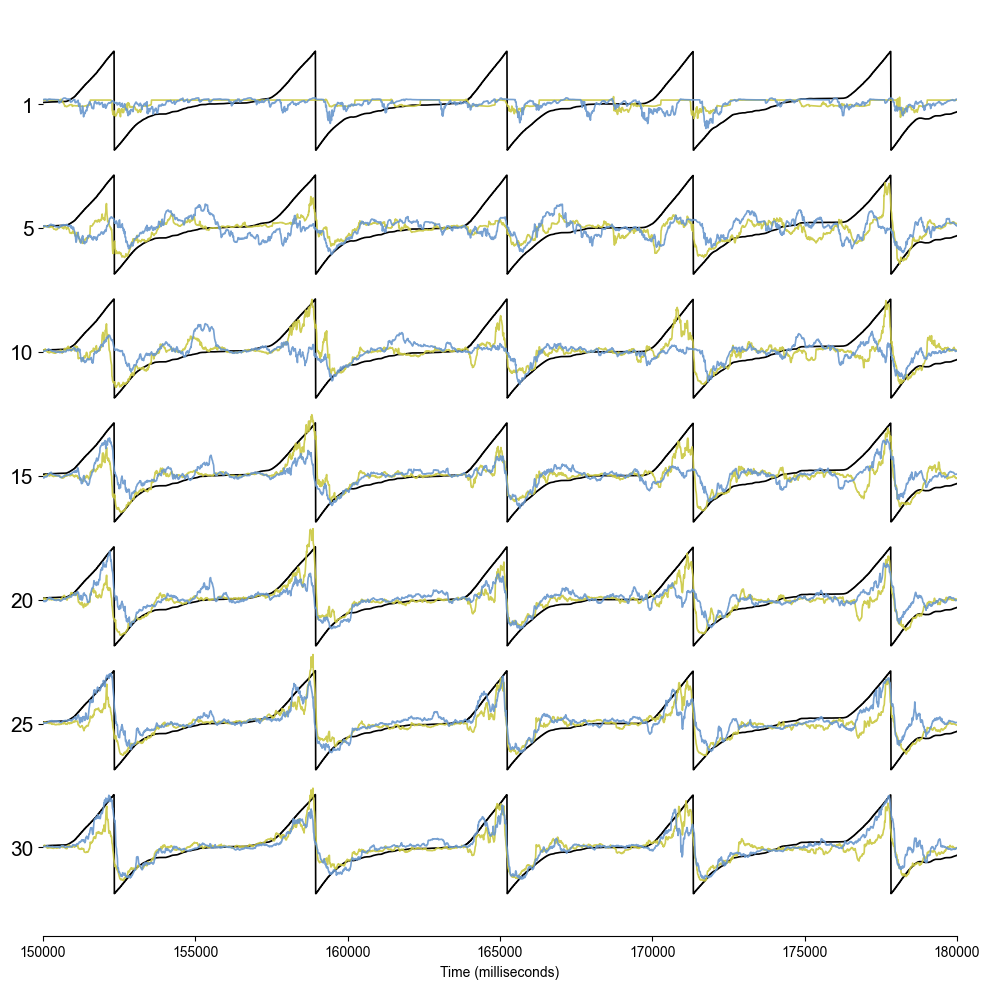

: 

In [ ]:
# Overlay: For each n_cells, overlay grid and NGS predictions on top of true, stacked from top (n=1) to bottom (n=30)

n_cells_to_plot = n_cells_list  # [1, 5, 10, 15, 20, 25, 30]
colors = {'grid': '#CAC841', 'ngs': '#6897CD', 'true': 'black'}
labels = {'grid': 'Grid', 'ngs': 'NGS', 'true': 'True'}
offset = 250  # vertical offset between traces (in cm), increased for more space
start = 15000
end = 18000

fig, ax = plt.subplots(figsize=(10, 10))
sf = 1  # scale factor for the y-axis

yticks = []
yticklabels = []

for i, n_cells in enumerate(n_cells_to_plot):
    idx = n_cells_list.index(n_cells)
    y_base = offset * (len(n_cells_to_plot) - 1 - i)
    # True position (PLOT FIRST, SO IT'S UNDER)
    ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, pos_in_time[start:end]*sf + y_base,
            color=colors['true'], linewidth=1.2, label='True' if i == 0 else None, zorder=1)
    # Grid prediction (PLOT SECOND, ON TOP)
    grid_pred = predictions['grid'][idx][0]
    ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, grid_pred[start:end]*sf + y_base,
            color=colors['grid'], linewidth=1.2, label='Grid' if i == 0 else None, alpha=0.9, zorder=2)
    # NGS prediction (PLOT THIRD, ON TOP)
    ngs_pred = predictions['ngs'][idx][0]
    if not np.all(np.isnan(ngs_pred)):
        ax.plot(np.arange(len(pos_in_time))[start:end]*time_bs, ngs_pred[start:end]*sf + y_base,
                color=colors['ngs'], linewidth=1.2, label='NGS' if i == 0 else None, alpha=0.9, zorder=3)
    # y-ticks
    yticks.append(y_base + np.mean(pos_in_time[start:end]*sf))
    yticklabels.append(f'{n_cells}')

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=15)
ax.set_xlabel('Time (milliseconds)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(start*time_bs, end*time_bs)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_overlay_true_vs_pred_all_ncells_overlay.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [25]:
pos_in_time.shape

(180726,)

plot a grid cell

In [ ]:
print('plot a grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[gcs.cluster_id.values[9]]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[gcs.cluster_id.values[10]]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a ngs cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[ngs.cluster_id.values[2]]), bs=bs, tl=tl, p=95)
plt.show()

In [ ]:
gcs_minus_test = gcs[gcs.cluster_id != gcs.cluster_id.values[9]]
cov_tcs_time_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs_minus_test.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_cere = {cluster_id: tcs_time[cluster_id] for cluster_id in cere.cluster_id.values if cluster_id in tcs_time}

In [ ]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

y = np.array(tcs_time[gcs.cluster_id.values[9]])
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[gcs.cluster_id.values[10]])]).T # grid cell 10
Xngs1 = np.stack([np.array(tcs_time[ngs.cluster_id.values[2]])]).T # ngs cell 2
Xcere1 = np.stack([np.array(tcs_time[cere.cluster_id.values[0]])]).T # cerebellar cell 0

Xgmax = np.column_stack((np.vstack(list(cov_tcs_time_grids.values())).T)).T # grid cells         
Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid spatial cells        
Xceremax = np.column_stack((np.vstack(list(cov_tcs_time_cere.values())).T)).T # cerebellar cells        

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[gcs.cluster_id.values[10]])]).T # grid cell 10 + pos in time
Xpos_ngs1 = np.stack([pos_in_time, np.array(tcs_time[ngs.cluster_id.values[2]])]).T # ngs cell 2 + pos in time
Xpos_cere1 = np.stack([pos_in_time, np.array(tcs_time[cere.cluster_id.values[0]])]).T  # cerebellar cell 0 + pos in time

Xpos_gmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_grids.values())).T)) # grid cells + pos in time     
Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid spatial cells + pos in time      
Xpos_ceremax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_cere.values())).T)) # cerebellar cells + pos in time       


Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)

Y_hat_g1, pR2_cv_g1 = xgb_history.fit_cv(Xg1, y, verbose = 0, continuous_folds = True)
Y_hat_ngs1, pR2_cv_ngs1 = xgb_history.fit_cv(Xngs1, y, verbose = 0, continuous_folds = True)
Y_hat_cere1, pR2_cv_cere1 = xgb_history.fit_cv(Xcere1, y, verbose = 0, continuous_folds = True)

Y_hat_gmax, pR2_cv_gmax = xgb_history.fit_cv(Xgmax, y, verbose = 0, continuous_folds = True)
Y_hat_ngsmax, pR2_cv_ngsmax = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)
Y_hat_ceremax, pR2_cv_ceremax = xgb_history.fit_cv(Xceremax, y, verbose = 0, continuous_folds = True)   

Y_hat_pos_g1, pR2_cv_pos_g1 = xgb_history.fit_cv(Xpos_g1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs1, pR2_cv_pos_ngs1 = xgb_history.fit_cv(Xpos_ngs1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_cere1, pR2_cv_pos_cere1 = xgb_history.fit_cv(Xpos_cere1, y, verbose = 0, continuous_folds = True)

Y_hat_pos_gmax, pR2_cv_pos_gmax = xgb_history.fit_cv(Xpos_gmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngsmax, pR2_cv_pos_ngsmax = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ceremax, pR2_cv_pos_ceremax = xgb_history.fit_cv(Xpos_ceremax, y, verbose = 0, continuous_folds = True)  

In [ ]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_p))[start:end]*time_bs, Y_hat_p[start:end]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1))[start:end]*time_bs, Y_hat_g1[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_ngs1))[start:end]*time_bs, Y_hat_ngs1[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='NGS cell 2')
ax.plot(np.arange(len(Y_hat_cere1))[start:end]*time_bs, Y_hat_cere1[start:end]*sf + (offset*4), color='#DAB978', linewidth=lw, label='Cerebellar cell 0')
ax.plot(np.arange(len(Y_hat_gmax))[start:end]*time_bs, Y_hat_gmax[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ngsmax))[start:end]*time_bs, Y_hat_ngsmax[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='NGS cells')
ax.plot(np.arange(len(Y_hat_ceremax))[start:end]*time_bs, Y_hat_ceremax[start:end]*sf + (offset*7), color='#DAB978', linewidth=lw, label='Cerebellar cells')   
ax.plot(np.arange(len(Y_hat_pos_g1))[start:end]*time_bs, Y_hat_pos_g1[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
ax.plot(np.arange(len(Y_hat_pos_ngs1))[start:end]*time_bs, Y_hat_pos_ngs1[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
ax.plot(np.arange(len(Y_hat_pos_cere1))[start:end]*time_bs, Y_hat_pos_cere1[start:end]*sf + (offset*10), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cell 0')
ax.plot(np.arange(len(Y_hat_pos_gmax))[start:end]*time_bs, Y_hat_pos_gmax[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
ax.plot(np.arange(len(Y_hat_pos_ngsmax))[start:end]*time_bs, Y_hat_pos_ngsmax[start:end]*sf + (offset*12), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
ax.plot(np.arange(len(Y_hat_pos_ceremax))[start:end]*time_bs, Y_hat_pos_ceremax[start:end]*sf + (offset*13), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cells')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:orange')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs1[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_cere1[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_cere1):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_gmax[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ceremax[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ceremax):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs1[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cere1[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_cere1):.2f}', va='center', fontsize=8, color='#DAB978')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gmax[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ceremax[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ceremax):.2f}', va='center', fontsize=8, color='#DAB978')

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_example_trained_on_grid_cell_9_mouse{mouse}_day{day}.pdf', bbox_inches='tight')
plt.show()


We can use different trial conditions of task-anchored labels to assess the difference of predictive accuracy in different parts of the session. Here we use task-anchored labels are plot the predictivity across groups

In [ ]:
labels_in_time = get_task_anchored_labels_in_time(mouse,day,cluster_ids_for_spectrogram=g_m_cluster_ids[0])

offset = 2  # vertical offset between traces
start=2000
end=3000
sf = -2 # scale factor for the y-axis
lw = 0.75
for label in np.unique(labels_in_time):
    print(f'Plotting label {label}')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(len(y[labels_in_time==label]))[start:end]*time_bs, y[labels_in_time==label][start:end]*sf, label='True', color='black', linewidth=lw)
    ax.plot(np.arange(len(Y_hat_p[labels_in_time==label]))[start:end]*time_bs, Y_hat_p[labels_in_time==label][start:end]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
    ax.plot(np.arange(len(Y_hat_g1[labels_in_time==label]))[start:end]*time_bs, Y_hat_g1[labels_in_time==label][start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ngs1[labels_in_time==label]))[start:end]*time_bs, Y_hat_ngs1[labels_in_time==label][start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='NGS cell 2')
    ax.plot(np.arange(len(Y_hat_cere1[labels_in_time==label]))[start:end]*time_bs, Y_hat_cere1[labels_in_time==label][start:end]*sf + (offset*4), color='#DAB978', linewidth=lw, label='Cerebellar cell 0')
    ax.plot(np.arange(len(Y_hat_gmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_gmax[labels_in_time==label][start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ngsmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_ngsmax[labels_in_time==label][start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='NGS cells')
    ax.plot(np.arange(len(Y_hat_ceremax[labels_in_time==label]))[start:end]*time_bs, Y_hat_ceremax[labels_in_time==label][start:end]*sf + (offset*7), color='#DAB978', linewidth=lw, label='Cerebellar cells')   
    ax.plot(np.arange(len(Y_hat_pos_g1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_g1[labels_in_time==label][start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ngs1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ngs1[labels_in_time==label][start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
    ax.plot(np.arange(len(Y_hat_pos_cere1[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_cere1[labels_in_time==label][start:end]*sf + (offset*10), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cell 0')
    ax.plot(np.arange(len(Y_hat_pos_gmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_gmax[labels_in_time==label][start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ngsmax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ngsmax[labels_in_time==label][start:end]*sf + (offset*12), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
    ax.plot(np.arange(len(Y_hat_pos_ceremax[labels_in_time==label]))[start:end]*time_bs, Y_hat_pos_ceremax[labels_in_time==label][start:end]*sf + (offset*13), color='#DAB978', linewidth=lw, linestyle='--', label='Position + Cerebellar cells')
    ax.set_xlabel('Time (millseconds)')

    # Annotate mean pR² values with superscript
    ax.text(end*time_bs + 10, np.mean(y[labels_in_time==label][start:end]*sf), 'True', va='center', fontsize=8, color='black')
    ax.text(end*time_bs + 10, np.mean(Y_hat_p[labels_in_time==label][start:end]*sf + offset), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_p[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='tab:orange')
    ax.text(end*time_bs + 10, np.mean(Y_hat_g1[labels_in_time==label][start:end]*sf + (offset*2)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_g1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ngs1[labels_in_time==label][start:end]*sf + (offset*3)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ngs1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_cere1[labels_in_time==label][start:end]*sf + (offset*4)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_cere1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_gmax[labels_in_time==label][start:end]*sf + (offset*5)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_gmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[labels_in_time==label][start:end]*sf + (offset*6)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ngsmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_ceremax[labels_in_time==label][start:end]*sf + (offset*7)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_ceremax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[labels_in_time==label][start:end]*sf + (offset*8)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_g1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs1[labels_in_time==label][start:end]*sf + (offset*9)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ngs1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cere1[labels_in_time==label][start:end]*sf + (offset*10)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_cere1[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gmax[labels_in_time==label][start:end]*sf + (offset*11)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_gmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#CAC841')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[labels_in_time==label][start:end]*sf + (offset*12)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ngsmax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#6897CD')
    ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ceremax[labels_in_time==label][start:end]*sf + (offset*13)), f'pR$^2$={poisson_pseudoR2(y[labels_in_time==label], Y_hat_pos_ceremax[labels_in_time==label], np.mean(y[labels_in_time==label])):.2f}', va='center', fontsize=8, color='#DAB978') 
    #ax.legend()
    # remove top, left and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()



we can see that various combinations of covariates can predict the grid cell activity to various degrees 

Now we will visual the effect of the history parameter


In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xg1.copy() # grid cell 10

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#CAC841', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#CAC841', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#CAC841', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#CAC841', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#CAC841', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#CAC841', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#CAC841', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#CAC841')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#CAC841')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#CAC841')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xgmax.copy() # grid cells

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#CAC841', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#CAC841', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#CAC841', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#CAC841', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#CAC841', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#CAC841', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#CAC841', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#CAC841')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#CAC841')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#CAC841')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




repeat this using a non grid cell as the covariate

In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]])
X = Xngs1.copy() # ngs cell 2

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#6897CD', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#6897CD', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#6897CD', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#6897CD', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#6897CD', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#6897CD', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#6897CD')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#6897CD')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#6897CD')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




repeat this using all the non grid cells 

In [ ]:
xgb_history = [MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = x) for x in [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]]
y = np.array(tcs_time[gcs.cluster_id.values[9]]) # ngs cell 2
X = Xngsmax.copy() # non grid spatial cells

Y_hat_g1_h1, pR2_cv_g1_h1 = xgb_history[0].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h2, pR2_cv_g1_h2 = xgb_history[1].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h3, pR2_cv_g1_h3 = xgb_history[2].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h4, pR2_cv_g1_h4 = xgb_history[3].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h5, pR2_cv_g1_h5 = xgb_history[4].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h6, pR2_cv_g1_h6 = xgb_history[5].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h7, pR2_cv_g1_h7 = xgb_history[6].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h8, pR2_cv_g1_h8 = xgb_history[7].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h9, pR2_cv_g1_h9 = xgb_history[8].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h10, pR2_cv_g1_h10 = xgb_history[9].fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1_h11, pR2_cv_g1_h11 = xgb_history[10].fit_cv(X, y, verbose = 0, continuous_folds = True)

offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=0
end=1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf, label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(Y_hat_g1_h1))[start:end]*time_bs, Y_hat_g1_h1[start:end]*sf + offset, color='#6897CD', linewidth=lw, label='history 1')
ax.plot(np.arange(len(Y_hat_g1_h2))[start:end]*time_bs, Y_hat_g1_h2[start:end]*sf + (offset*2), color='#6897CD', linewidth=lw, label='history 2')
ax.plot(np.arange(len(Y_hat_g1_h3))[start:end]*time_bs, Y_hat_g1_h3[start:end]*sf + (offset*3), color='#6897CD', linewidth=lw, label='history 3')
ax.plot(np.arange(len(Y_hat_g1_h4))[start:end]*time_bs, Y_hat_g1_h4[start:end]*sf + (offset*4), color='#6897CD', linewidth=lw, label='history 4')
ax.plot(np.arange(len(Y_hat_g1_h5))[start:end]*time_bs, Y_hat_g1_h5[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='history 5')
ax.plot(np.arange(len(Y_hat_g1_h6))[start:end]*time_bs, Y_hat_g1_h6[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='history 6')
ax.plot(np.arange(len(Y_hat_g1_h7))[start:end]*time_bs, Y_hat_g1_h7[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='history 7')
ax.plot(np.arange(len(Y_hat_g1_h8))[start:end]*time_bs, Y_hat_g1_h8[start:end]*sf + (offset*8), color='#6897CD', linewidth=lw, label='history 8')
ax.plot(np.arange(len(Y_hat_g1_h9))[start:end]*time_bs, Y_hat_g1_h9[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='history 9')
ax.plot(np.arange(len(Y_hat_g1_h10))[start:end]*time_bs, Y_hat_g1_h10[start:end]*sf + (offset*10), color='#6897CD', linewidth=lw, label='history 10')
ax.plot(np.arange(len(Y_hat_g1_h11))[start:end]*time_bs, Y_hat_g1_h11[start:end]*sf + (offset*11), color='#6897CD', linewidth=lw, label='history 11')

ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h1[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_g1_h1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h2[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1_h2):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h3[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g1_h3):.2f}', va='center', fontsize=8, color='#6897CD')  
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h4[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_g1_h4):.2f}', va='center', fontsize=8, color='#6897CD')      
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h5[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_g1_h5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h6[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_g1_h6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h7[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_g1_h7):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h8[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_g1_h8):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h9[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_g1_h9):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h10[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_g1_h10):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_h11[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_g1_h11):.2f}', va='center', fontsize=8, color='#6897CD')
#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()




appendix 1 hyperparameter search

In [ ]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


In [ ]:
hyperoptBest